## Simran Kukreja [25141104]

## Jai Parakh [25165933]

The given code executes till the end without errors. One just needs to downlaod the dataset folder and update the path.

Model Link: [Pythorch Documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.convnext_tiny.html#torchvision.models.convnext_tiny)

### Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import random
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Global Variables

In [2]:
# Path for downlaoded npy files
dataset_path = 'numpy_data/numpy_bitmap'

# Since there are 70k+ images per class, we use only 10k due to hardware limitations.
IMAGES_PER_CLASS = 10000

# Batch size for data loaders (train/test/validate)
BATCH_SIZE = 32

# Same seed for reproducibility
SEED = 66

# Epochs for model training
EPOCHS = 10

# Number of files (classes) to process
FILES_LEN = 30

### Cuda Configuration

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Dataset Loading

Google Quickdraw
[Dataset Link](https://github.com/googlecreativelab/quickdraw-dataset)

In [4]:
files = os.listdir(dataset_path)[:FILES_LEN]
classes = []

all_images = []
all_labels = []
for index, file in enumerate(files):
    class_name = file.replace(' ', '_').replace('.npy', '')
    classes.append(class_name)
    data = np.load(os.path.join(dataset_path, file)).astype(np.float32)
    data = data[:IMAGES_PER_CLASS]
    
    # Normalize pixel values to [0, 1]
    data = data / 255.0
    data = data.reshape(-1, 28, 28)
    all_images.extend(data)
    all_labels.extend([index] * len(data))


all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f"Total images: {len(all_images)}, Total labels: {len(classes)}")

Total images: 300000, Total labels: 30


### Dataset Visualisation

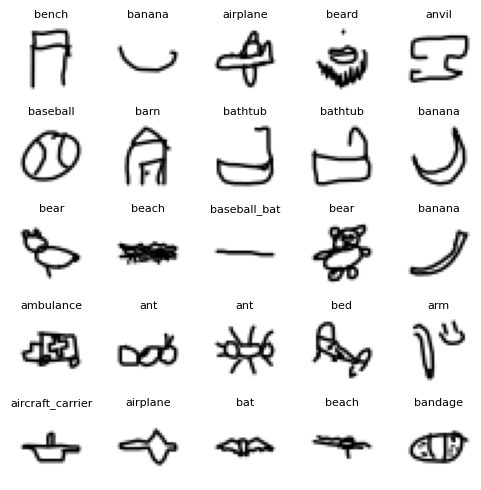

In [5]:
def plot_sampls_with_labels(data, labels, class_names, n=5):
    # n * n grid of images
    plt.figure(figsize=(n, n))
    for i in range(n * n):
        index = np.random.randint(0, len(data))

        plt.subplot(n, n, i + 1)
        plt.imshow(data[index], cmap='gray_r')

        class_idx = labels[index]
        class_name = class_names[class_idx]
        plt.title(class_name, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_sampls_with_labels(all_images, all_labels, classes)

#### Here we compare how any random image of a class differs from the mean of that class

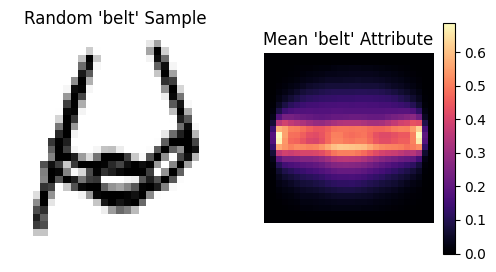

In [6]:
sample_index = np.random.randint(0, len(all_images))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(all_images[sample_index], cmap='gray_r')
axes[0].set_title(f"Random '{classes[all_labels[sample_index]]}' Sample")
axes[0].axis('off')

# Floor division to get the class index
class_index = sample_index // IMAGES_PER_CLASS

# We compute the start and end index of the class
subimages_x = all_images[IMAGES_PER_CLASS * class_index : (IMAGES_PER_CLASS * class_index + IMAGES_PER_CLASS)]

mean_img = np.mean(subimages_x, axis=0)
image = axes[1].imshow(mean_img, cmap='magma')
axes[1].set_title(f"Mean '{classes[all_labels[sample_index]]}' Attribute")
axes[1].axis('off')

plt.colorbar(image, ax=axes[1])
plt.show()

barn Sparsity: 22.96%
arm Sparsity: 18.24%
bed Sparsity: 22.58%


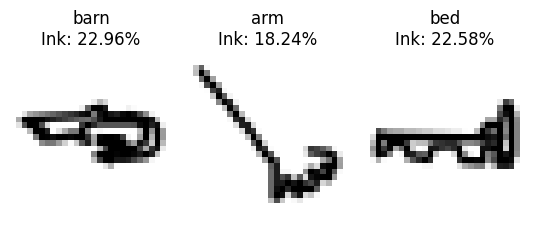

In [7]:
random_indices = np.random.choice(len(all_images), 3, replace=False)

plt.figure(figsize=(9, 4))

for i, idx in enumerate(random_indices):
    img = all_images[idx]
    label = classes[all_labels[idx]]

    ink_pixels = np.count_nonzero(img)
    sparsity_val = (ink_pixels / 784.0) * 100

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray_r')
    plt.title(f"{label}\nInk: {sparsity_val:.2f}%")
    plt.axis('off')

    print(f"{label} Sparsity: {sparsity_val:.2f}%")

plt.tight_layout()
plt.show()


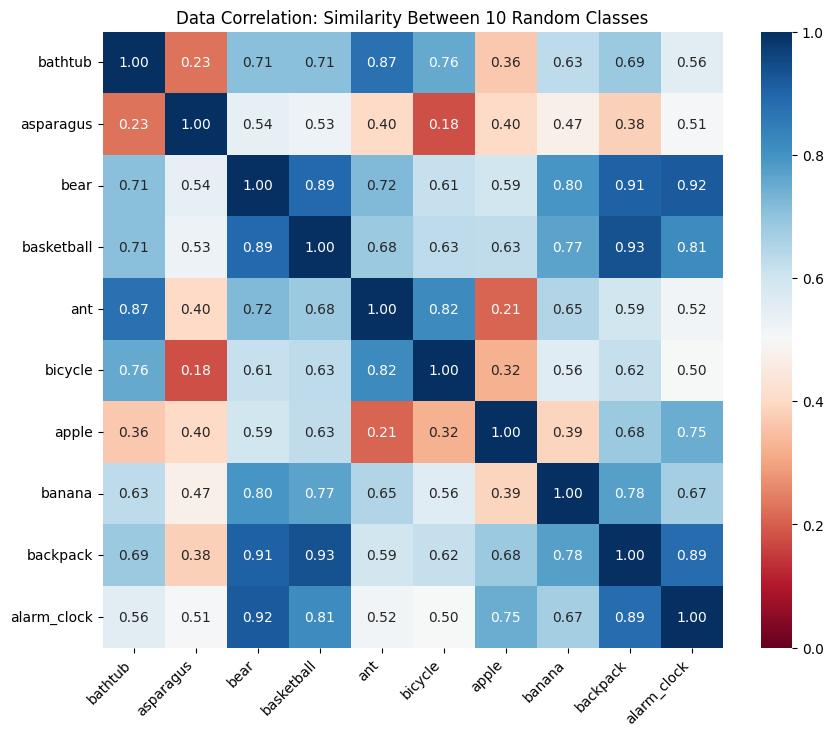

In [8]:
# this is how much similar images are comparing with different ctaegories i.e correlation of images with each other(different category)
random_indices = np.random.choice(range(len(classes)), 10, replace=False)
selected_names = [classes[i] for i in random_indices]

means = []
for idx in random_indices:
    mean_img = np.mean(all_images[all_labels == idx], axis=0).flatten()
    means.append(mean_img)

corr_matrix = np.corrcoef(means)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', xticklabels=selected_names, yticklabels=selected_names, fmt=".2f", vmin=0, vmax=1)

plt.title(f"Data Correlation: Similarity Between 10 Random Classes")
plt.xticks(rotation=45, ha='right')
plt.show()


### Data Split

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images,
    all_labels,
    test_size=0.3,
    random_state=SEED,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Final split sizes:")
print(f"Train: {len(X_train)} ({len(X_train) / len(all_images) * 100}%)")
print(f"Val: {len(X_val)} ({len(X_val) / len(all_images) * 100}%)")
print(f"Test: {len(X_test)} ({len(X_test) / len(all_images) * 100}%)")

Final split sizes:
Train: 210000 (70.0%)
Val: 45000 (15.0%)
Test: 45000 (15.0%)


### Feature Engineering

In [10]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((56, 56)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

def apply_transform(images, transform, seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    return torch.stack([transform(img) for img in tqdm(images)])


print("Applying transforms to training set")
X_train_tensor = apply_transform(X_train, transform)

print("Applying transforms to validation set")
X_val_tensor = apply_transform(X_val, transform)

print("Applying transforms to test set")
X_test_tensor = apply_transform(X_test, transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"\nTensor shapes:")
print(f"Train: {X_train_tensor.shape}")
print(f"Val: {X_val_tensor.shape}")
print(f"Test: {X_test_tensor.shape}")

Applying transforms to training set


100%|██████████| 210000/210000 [01:33<00:00, 2237.34it/s]


Applying transforms to validation set


100%|██████████| 45000/45000 [00:18<00:00, 2452.89it/s]


Applying transforms to test set


100%|██████████| 45000/45000 [00:18<00:00, 2425.68it/s]



Tensor shapes:
Train: torch.Size([210000, 1, 56, 56])
Val: torch.Size([45000, 1, 56, 56])
Test: torch.Size([45000, 1, 56, 56])


### Data Loading

In [11]:
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'), generator=g)

print(f"Batches: Train {len(train_loader)}, Val {len(val_loader)}, Test {len(test_loader)}")

Batches: Train 6563, Val 1407, Test 1407


### COmmon Training code

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    # Model set to trianing
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # We reset gradient after every batch to avoid accumulation (loss.backwards() accumultes these gradients)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # We update the weights here
        optimizer.step()

        # Stats
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Avg loss and accuracy across all batches
    return running_loss / len(loader), 100 * correct / total

def validate_epoch(model, loader, criterion, device):
    # Model set to Eval mode
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # Since its validation we dont compute gradients here
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # STats
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [13]:
def training_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, model_name='model'):

    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Starting training")
    print("="*60)

    for epoch in range(EPOCHS):

        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # Train and validate for each epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc
            }, f'{model_name}_{epoch+1}.pth')
            print(f"New best model saved! (Val Acc: {val_acc:.2f}%)")

        print("="*60)

    print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")
    return history

### Common Loss and Accuracy Plots for training

In [14]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc', marker='o')
    ax2.plot(history['val_acc'], label='Val Acc', marker='o')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy Curves')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### ConvNext Model

#### 1. Pre Trained

In [15]:
num_classes = len(classes)

# For tiny model IMAGENET1K_V1 are the default weights
pretrained_model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

# Changed the input from 3 to 1 channel for grayscale images
pretrained_model.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4)

# Modify the classifier head
in_features = pretrained_model.classifier[2].in_features
pretrained_model.classifier[2] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, num_classes)
)

pretrained_model = pretrained_model.to(device)

print(pretrained_model)

total_params = sum(p.numel() for p in pretrained_model.parameters())
trainable_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [16]:
criterion = nn.CrossEntropyLoss()

# The reason for choosing adamW and cosine annealing was that the original convnext paper used them,
# and they are known to work well for vision transformers, which is what convNext is based on.
optimizer = optim.AdamW(pretrained_model.parameters(), lr=0.0005, weight_decay=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [17]:
# Trainign the model and saving the history
pretrained_model_history = training_model(pretrained_model, train_loader, val_loader, criterion, optimizer, scheduler, device, 'pretrained')

Starting training

Epoch 1/10


Validating: 100%|██████████| 1407/1407 [00:32<00:00, 43.26it/s]



Train Loss: 0.7200 | Train Acc: 79.81%
Val Loss: 0.5463 | Val Acc: 84.56%
LR: 0.000488
New best model saved! (Val Acc: 84.56%)

Epoch 2/10


Validating: 100%|██████████| 1407/1407 [00:31<00:00, 44.05it/s]



Train Loss: 0.5232 | Train Acc: 85.37%
Val Loss: 0.5211 | Val Acc: 85.66%
LR: 0.000452
New best model saved! (Val Acc: 85.66%)

Epoch 3/10


...


Train Loss: 0.1372 | Train Acc: 95.86%
Val Loss: 0.5535 | Val Acc: 87.41%
LR: 0.000048

Epoch 9/10


Validating: 100%|██████████| 1407/1407 [00:32<00:00, 42.66it/s]



Train Loss: 0.0774 | Train Acc: 97.73%
Val Loss: 0.5956 | Val Acc: 87.49%
LR: 0.000012
New best model saved! (Val Acc: 87.49%)

Epoch 10/10


Validating: 100%|██████████| 1407/1407 [00:29<00:00, 48.17it/s]



Train Loss: 0.0450 | Train Acc: 98.73%
Val Loss: 0.6093 | Val Acc: 87.77%
LR: 0.000000
New best model saved! (Val Acc: 87.77%)

Training complete! Best validation accuracy: 87.77%


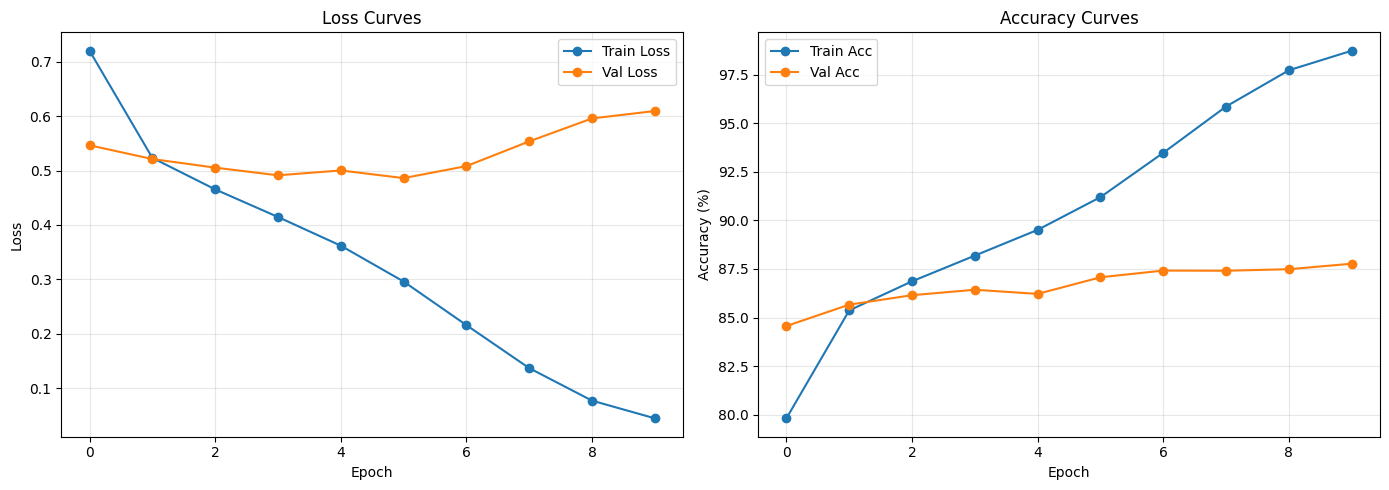

In [18]:
# Plot the model history
plot_history(pretrained_model_history)

#### 2. Training from scratch

In [19]:
num_classes = len(classes)

# Load convnext tiny with random weights (no pretrained weights)
scratch_model = convnext_tiny(weights=None)
print("Loaded ConvNeXt Tiny with rNandom weights")

# Changed the input from 3 to 1 channel for grayscale images
scratch_model.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4)

# Modify the classifier head
in_features = scratch_model.classifier[2].in_features
scratch_model.classifier[2] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, num_classes)
)

scratch_model = scratch_model.to(device)

print(scratch_model)

total_params = sum(p.numel() for p in scratch_model.parameters())
trainable_params = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loaded ConvNeXt Tiny with rNandom weights
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affin

In [20]:
criterion = nn.CrossEntropyLoss()

# The reason for choosing adamW and cosine annealing was that the original convnext paper used them,
# and they are known to work well for vision transformers, which is what convNext is based on.

# Since weights are random, we can use a higher learning rate to help the model converge faster, weight decay stays the same as pretrained model.
optimizer = optim.AdamW(scratch_model.parameters(), lr=0.01, weight_decay=0.1)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [21]:
# Training the model and saving the history
scratch_model_history = training_model(scratch_model, train_loader, val_loader, criterion, optimizer, scheduler, device, 'scratch')

Starting training

Epoch 1/10


Validating: 100%|██████████| 1407/1407 [00:33<00:00, 41.80it/s]



Train Loss: 1.8610 | Train Acc: 47.21%
Val Loss: 1.4724 | Val Acc: 57.65%
LR: 0.009755
New best model saved! (Val Acc: 57.65%)

Epoch 2/10


Validating: 100%|██████████| 1407/1407 [00:37<00:00, 37.26it/s]



Train Loss: 1.4118 | Train Acc: 60.00%
Val Loss: 1.3292 | Val Acc: 62.03%
LR: 0.009045
New best model saved! (Val Acc: 62.03%)

Epoch 3/10


...


Train Loss: 0.8289 | Train Acc: 76.84%
Val Loss: 0.8120 | Val Acc: 77.10%
LR: 0.000955
New best model saved! (Val Acc: 77.10%)

Epoch 9/10


Validating: 100%|██████████| 1407/1407 [00:30<00:00, 45.56it/s]



Train Loss: 0.6932 | Train Acc: 80.70%
Val Loss: 0.7094 | Val Acc: 80.27%
LR: 0.000245
New best model saved! (Val Acc: 80.27%)

Epoch 10/10


Validating: 100%|██████████| 1407/1407 [00:32<00:00, 43.07it/s]



Train Loss: 0.5444 | Train Acc: 84.76%
Val Loss: 0.5896 | Val Acc: 83.88%
LR: 0.000000
New best model saved! (Val Acc: 83.88%)

Training complete! Best validation accuracy: 83.88%


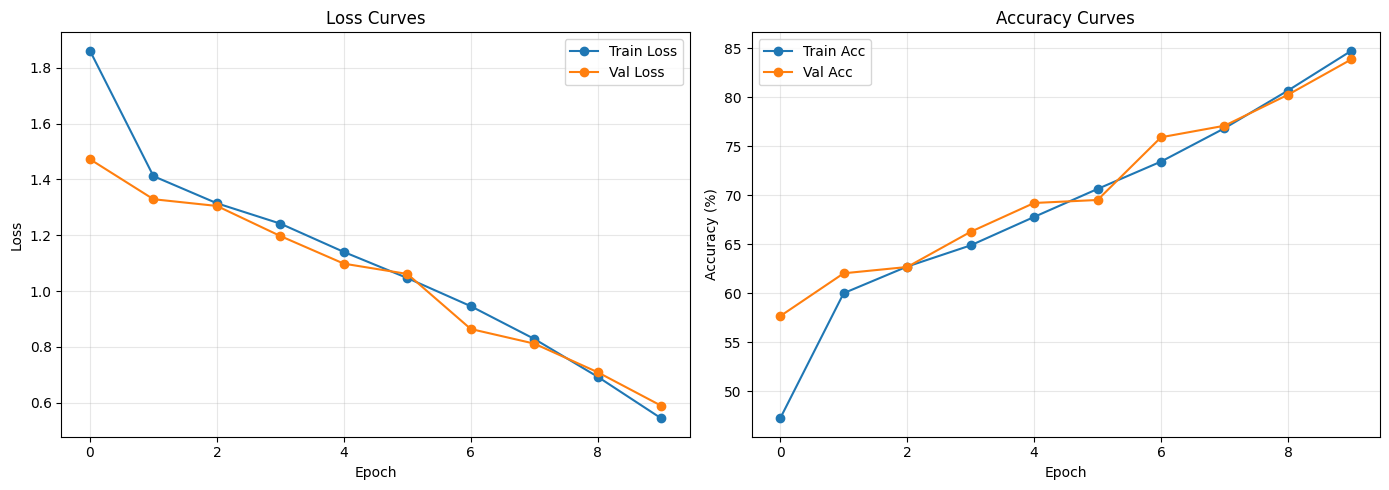

In [22]:
# Plot the model history
plot_history(scratch_model_history)

### Comparing both the models

In [23]:
test_loss_scratch, test_acc_scratch, test_preds_scratch, test_labels_scratch = validate_epoch(
    scratch_model, test_loader, criterion, device
)
print(f"Test Results: Model trained from scratch")
print(f"Test Loss: {test_loss_scratch:.4f}")
print(f"Test Accuracy: {test_acc_scratch:.2f}%")
print("Classification Report:")
print(classification_report(test_labels_scratch, test_preds_scratch, target_names=classes, digits=4))

print("="*60)

test_loss_pretrained, test_acc_pretrained, test_preds_pretrained, test_labels_pretrained = validate_epoch(
    pretrained_model, test_loader, criterion, device
)
print(f"Test Results: Model trained with pre-trained weights")
print(f"Test Loss: {test_loss_pretrained:.4f}")
print(f"Test Accuracy: {test_acc_pretrained:.2f}%")
print("Classification Report:")
print(classification_report(test_labels_pretrained, test_preds_pretrained, target_names=classes, digits=4))

Validating: 100%|██████████| 1407/1407 [00:31<00:00, 45.01it/s]


Test Results: Model trained from scratch
Test Loss: 0.5909
Test Accuracy: 83.84%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.5899    0.5227    0.5543      1500
        airplane     0.8149    0.8540    0.8340      1500
     alarm_clock     0.8496    0.8660    0.8577      1500
       ambulance     0.9097    0.9273    0.9185      1500
           angel     0.8820    0.8520    0.8667      1500
animal_migration     0.6756    0.7927    0.7294      1500
             ant     0.8828    0.8333    0.8573      1500
           anvil     0.9301    0.9047    0.9172      1500
           apple     0.9392    0.9573    0.9482      1500
             arm     0.8348    0.8420    0.8384      1500
       asparagus     0.7964    0.8607    0.8273      1500
             axe     0.8951    0.8987    0.8969      1500
        backpack     0.8655    0.8580    0.8617      1500
          banana     0.9149    0.9313    0.9230      1500
         bandage     0.89

Validating: 100%|██████████| 1407/1407 [00:31<00:00, 44.13it/s]

Test Results: Model trained with pre-trained weights
Test Loss: 0.6097
Test Accuracy: 87.88%
Classification Report:
                  precision    recall  f1-score   support

aircraft_carrier     0.6616    0.6060    0.6326      1500
        airplane     0.8109    0.8720    0.8403      1500
     alarm_clock     0.9051    0.9220    0.9135      1500
       ambulance     0.9510    0.9453    0.9482      1500
           angel     0.8998    0.8920    0.8959      1500
animal_migration     0.8252    0.7960    0.8103      1500
             ant     0.8781    0.9173    0.8973      1500
           anvil     0.9414    0.9107    0.9258      1500
           apple     0.9692    0.9647    0.9669      1500
             arm     0.9175    0.8900    0.9036      1500
       asparagus     0.8694    0.8613    0.8654      1500
             axe     0.9462    0.9267    0.9363      1500
        backpack     0.8889    0.9013    0.8951      1500
          banana     0.9134    0.9493    0.9310      1500
         band